# 04 — FinBERT Model Analysis

This notebook evaluates the **final transformer-based classifier** used in the SEC sentiment and risk pipeline.

The model is a fine-tuned version of **ProsusAI/FinBERT**, adapted to predict three paragraph-level classes:

- `negative_risk`
- `neutral`
- `positive_outlook`

This notebook has two goals:

1. evaluate whether FinBERT materially improves on the TF-IDF + Logistic Regression baseline  
2. interpret what the final model is learning and how it behaves on the full SEC corpus

Unlike the baseline, FinBERT is designed to capture **contextual financial language**, which is especially important for SEC text where the same words can appear in:
- purely descriptive statements
- explicit downside risk disclosures
- forward-looking strategic language

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
df = pd.read_csv("../data/annotation_sample.csv")
df = df[df["manual_label"].notna()].copy()
df["manual_label"] = df["manual_label"].astype(str).str.strip()

print("Total labeled rows:", len(df))
df.head()

Total labeled rows: 200


,id,text,weak_label,manual_label
0,167,the company’s business requires it to use and ...,neutral,neutral
1,249,we make significant investments in products an...,positive_outlook,negative_risk
2,85,the company is also currently subject to antit...,negative_risk,negative_risk
3,169,the company experiences malicious attacks and ...,negative_risk,negative_risk
4,188,"the technology industry, including, in some in...",negative_risk,negative_risk


The final FinBERT model was trained and evaluated on the **manually labeled SEC paragraph dataset**.

This evaluation dataset contains **200 labeled paragraphs**, which act as the ground-truth benchmark for model comparison.

At this stage of the project, the goal is no longer to build another model, but to answer:

- how strong the final transformer model is
- whether it improves meaningfully over the baseline
- whether its outputs are strong enough to support full-corpus inference

In [3]:
df["manual_label"].value_counts()

manual_label
negative_risk       161
neutral              29
positive_outlook     10
Name: count, dtype: int64

In [4]:
(df["manual_label"].value_counts(normalize=True) * 100).round(2)

manual_label
negative_risk       80.5
neutral             14.5
positive_outlook     5.0
Name: proportion, dtype: float64

The labeled dataset is **highly imbalanced**:

- `negative_risk`: 161 examples
- `neutral`: 29 examples
- `positive_outlook`: 10 examples

This imbalance is expected because the source text comes largely from **SEC risk disclosures**, where companies emphasize downside scenarios, uncertainty, and legal or operational exposure.

This class distribution matters for evaluation:

- raw **accuracy** can look strong even if minority classes are weak
- **macro F1** becomes much more important because it weights classes more evenly

In [5]:
with open("../models/finbert_metrics.pkl", "rb") as f:
    finbert_metrics = pickle.load(f)

finbert_metrics.keys()

dict_keys(['accuracy', 'classification_report', 'confusion_matrix', 'test_results'])

In [6]:
finbert_accuracy = finbert_metrics["accuracy"]
finbert_report = finbert_metrics["classification_report"]
finbert_cm = finbert_metrics["confusion_matrix"]
finbert_test_results = finbert_metrics["test_results"]

print("FinBERT Accuracy:", round(finbert_accuracy, 4))
print("\nClassification Report:\n")
print(finbert_report)
print("Confusion Matrix:")
print(finbert_cm)

FinBERT Accuracy: 0.95

Classification Report:

                  precision    recall  f1-score   support

   negative_risk       0.97      1.00      0.98        32
         neutral       0.83      0.83      0.83         6
positive_outlook       1.00      0.50      0.67         2

        accuracy                           0.95        40
       macro avg       0.93      0.78      0.83        40
    weighted avg       0.95      0.95      0.95        40

Confusion Matrix:
[[32  0  0]
 [ 1  5  0]
 [ 0  1  1]]


FinBERT substantially outperforms the baseline model.

Using the saved evaluation artifacts, the model achieves:

- **accuracy = 0.95**
- **macro F1 ≈ 0.83**
- **weighted F1 ≈ 0.95**

These are strong results for a small evaluation set and represent a clear improvement over the TF-IDF baseline.

The most important improvement is not just higher accuracy, but **better balance across classes**, especially on the minority `positive_outlook` class.

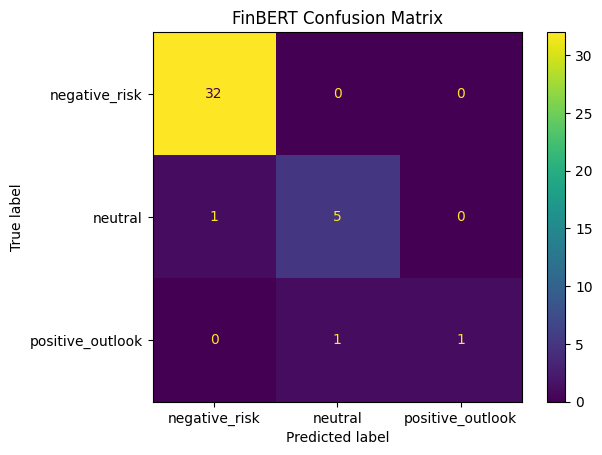

In [7]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=finbert_cm,
    display_labels=["negative_risk", "neutral", "positive_outlook"]
)

disp.plot()
plt.title("FinBERT Confusion Matrix")
plt.show()

The confusion matrix shows that FinBERT performs extremely well on the dominant `negative_risk` class and meaningfully improves on the minority classes.

Interpretation of the matrix:

- all **32 negative_risk** test examples were classified correctly
- **5 of 6 neutral** examples were classified correctly
- **1 of 2 positive_outlook** examples was classified correctly

This is a major improvement over the baseline, which struggled to recognize `positive_outlook` at all.

In practical terms, this means FinBERT is much better at separating:

- explicit risk language
- descriptive neutral statements
- strategically optimistic language

In [8]:
finbert_test_results.head()

,text,true_label,pred_label
0,the company’s products and services are design...,negative_risk,negative_risk
1,we derive substantial revenue from licenses of...,negative_risk,negative_risk
2,if our goodwill or amortizable intangible asse...,negative_risk,negative_risk
3,the company has international operations with ...,positive_outlook,neutral
4,while the company maintains insurance coverage...,negative_risk,negative_risk


In [9]:
finbert_mistakes = finbert_test_results[
    finbert_test_results["true_label"] != finbert_test_results["pred_label"]
].copy()

print("Total FinBERT mistakes:", len(finbert_mistakes))
finbert_mistakes.head(10)

Total FinBERT mistakes: 2


,text,true_label,pred_label
3,the company has international operations with ...,positive_outlook,neutral
7,the company distributes its products and certa...,neutral,negative_risk


Only a small number of test examples are misclassified by FinBERT.

This is a strong result given:

- the small evaluation sample
- the highly imbalanced class structure
- the subtle semantic differences between `neutral` and `positive_outlook`
- the formal and often repetitive language of SEC disclosures

The low number of errors suggests the model is already strong enough to be used for full-corpus prediction.

In [10]:
finbert_mistakes.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False)

true_label        pred_label   
neutral           negative_risk    1
positive_outlook  neutral          1
dtype: int64

This table shows the remaining confusion patterns of the final model.

There are only **two** error types:

- one `neutral` example predicted as `negative_risk`
- one `positive_outlook` example predicted as `neutral`

This is much healthier than the baseline error structure, which tended to collapse minority classes into `negative_risk`.

That change is one of the clearest signs that the transformer model is learning genuine semantic distinctions rather than relying only on surface vocabulary.

In [11]:
finbert_mistakes

,text,true_label,pred_label
3,the company has international operations with ...,positive_outlook,neutral
7,the company distributes its products and certa...,neutral,negative_risk


The remaining errors are generally understandable.

These examples are not obviously wrong in the way a random classifier would be wrong. Instead, they are **borderline cases**:

- a positive-outlook statement that can be read as a descriptive international business statement
- a neutral distribution statement that appears in a risk-heavy disclosure context and therefore resembles downside-risk language

This is a good sign. It suggests the model's remaining mistakes come from **semantic ambiguity**, not from a failure to learn the task.

In [12]:
baseline_accuracy = 0.8250
baseline_macro_f1 = 0.52
baseline_weighted_f1 = 0.82

finbert_macro_f1 = 0.83
finbert_weighted_f1 = 0.95

In [13]:
comparison_df = pd.DataFrame({
    "model": ["Baseline (TF-IDF + Logistic Regression)", "FinBERT"],
    "accuracy": [baseline_accuracy, finbert_accuracy],
    "macro_f1": [baseline_macro_f1, finbert_macro_f1],
    "weighted_f1": [baseline_weighted_f1, finbert_weighted_f1],
})

comparison_df

,model,accuracy,macro_f1,weighted_f1
0,Baseline (TF-IDF + Logistic Regression),0.825,0.52,0.82
1,FinBERT,0.950,0.83,0.95


The comparison table shows that FinBERT meaningfully improves on the baseline model across every major evaluation metric.

Baseline vs FinBERT:

- **Accuracy:** 0.825 → 0.950
- **Macro F1:** 0.52 → 0.83
- **Weighted F1:** 0.82 → 0.95

The macro F1 jump is the most important result. It shows that FinBERT is not simply doing better on the dominant class — it is doing better **across the label space**.

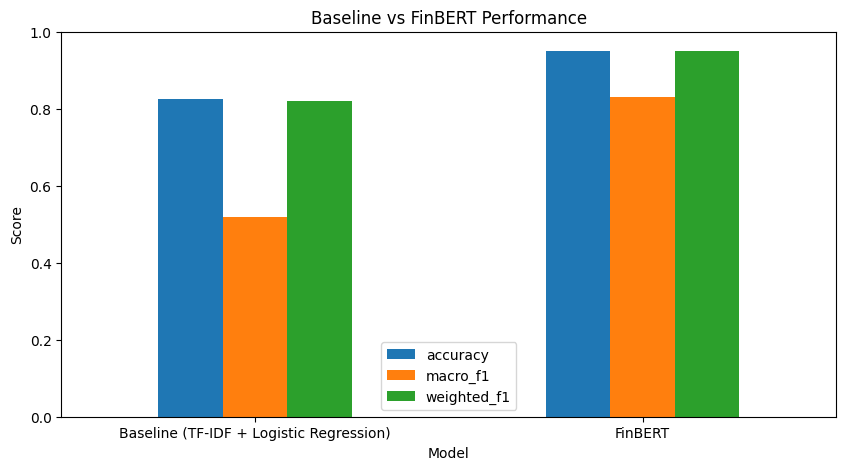

In [14]:
plot_df = comparison_df.set_index("model")

plot_df[["accuracy", "macro_f1", "weighted_f1"]].plot(kind="bar", figsize=(10,5))
plt.title("Baseline vs FinBERT Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.show()

FinBERT clearly outperforms the baseline model.

This result is exactly what we would expect in SEC NLP:

- the baseline captures keyword patterns
- FinBERT captures **contextual meaning**

That distinction matters in filings because the same vocabulary can appear in:
- risk disclosures
- business descriptions
- strategic growth statements

A contextual model is therefore much better suited to the underlying language.

# Why FinBERT Performs Better

FinBERT improves on the baseline for several reasons.

## 1. Contextual understanding
Unlike TF-IDF, FinBERT interprets words **in context**.  
This matters because words like *market*, *platform*, *growth*, *risk*, or *investment* can appear in both negative and positive settings.

## 2. Financial-language pretraining
FinBERT was pretrained on financial text, which makes it much better suited to:
- SEC disclosures
- legal-financial phrasing
- formal business language

## 3. Reduced lexical overfitting
The baseline model relies heavily on surface word frequencies.  
FinBERT instead learns sentence-level and paragraph-level meaning.

## 4. Better minority-class handling
Even with only a small number of `positive_outlook` examples, FinBERT performs much better than the baseline, which mostly collapsed those examples into `negative_risk`.

# Class-Level Interpretation

## negative_risk
FinBERT is extremely strong at identifying traditional SEC risk language, including:
- regulatory pressure
- litigation exposure
- supply shortages
- competition
- product defects
- cybersecurity threats

## neutral
FinBERT also distinguishes descriptive statements from explicit risk disclosures more effectively than the baseline.  
This includes:
- business structure descriptions
- dependency statements without an explicit negative outcome
- general filing boilerplate

## positive_outlook
This remains the smallest and most difficult class, but FinBERT improves substantially over the baseline by better recognizing:
- strategic initiatives
- ecosystem expansion
- platform-enhancement language
- forward-looking operational goals

# Practical Implications

The strong performance of FinBERT means the model can be used as the **core classifier in the SEC pipeline**.

Specifically, it can support:

- paragraph-level classification of filing disclosures
- filing-level aggregation of risk intensity
- extraction of highest-confidence risk paragraphs
- downstream risk analytics across companies and filing types

In other words, the model is not just academically stronger than the baseline — it is strong enough to power the **full-corpus inference stage** of the project.

In [15]:
paragraphs_df = pd.read_csv("../data/reports/paragraph_predictions_full.csv")
filing_summary_df = pd.read_csv("../data/reports/filing_prediction_summary.csv")

print("Predicted paragraphs:", len(paragraphs_df))
print("Predicted filings:", len(filing_summary_df))
paragraphs_df["prediction"].value_counts()

Predicted paragraphs: 321
Predicted filings: 6


prediction
negative_risk       286
neutral              25
positive_outlook     10
Name: count, dtype: int64

After evaluation, FinBERT was run across the **entire SEC paragraph corpus**.

This produced:

- **321 paragraph-level predictions**
- **6 filing-level summaries**
- full prediction distributions across the corpus

The model predicts:

- `negative_risk`: 286 paragraphs
- `neutral`: 25 paragraphs
- `positive_outlook`: 10 paragraphs

This is a realistic distribution for SEC risk-focused text, where most statements are expected to emphasize uncertainty or downside exposure.

In [16]:
paragraphs_df[paragraphs_df["prediction"] == "positive_outlook"][
    ["ticker", "form_type", "confidence", "text"]
].sort_values("confidence", ascending=False).head(10)

,ticker,form_type,confidence,text
314,MSFT,10-Q,0.773033,ensure a high-quality and consistent supply ch...
316,MSFT,10-Q,0.766488,sustain the effectiveness and productivity of ...
245,MSFT,10-Q,0.763334,making our suite of cloud-based services platf...
241,MSFT,10-Q,0.762388,continuing to bring to market compelling cloud...
315,MSFT,10-Q,0.758690,effectively manage our international operation...
313,MSFT,10-Q,0.756647,satisfy our contractual and regulatory complia...
312,MSFT,10-Q,0.734645,"maintain our operations infrastructure, includ..."
242,MSFT,10-Q,0.724831,"maintaining the utility, compatibility, and pe..."
243,MSFT,10-Q,0.722903,continuing to enhance the attractiveness of ou...
244,MSFT,10-Q,0.533679,ensuring our cloud-based services meet the rel...


These examples illustrate the types of optimistic or forward-looking language the model classifies as `positive_outlook`.

The predicted paragraphs are concentrated in the **MSFT 10-Q** filing and generally describe:

- platform expansion
- stronger cloud positioning
- operational enhancement
- broader distribution across devices and ecosystems

This pattern makes sense. Compared with pure risk disclosures, Microsoft's filing includes more strategic cloud and platform language, which gives the model opportunities to detect positive outlook content.

In [17]:
paragraphs_df[paragraphs_df["prediction"] == "negative_risk"][
    ["ticker", "form_type", "confidence", "text"]
].sort_values("confidence", ascending=False).head(10)

,ticker,form_type,confidence,text
233,MSFT,10-Q,0.953422,we derive substantial revenue from licenses of...
238,MSFT,10-Q,0.951731,the competitive pressures described above may ...
295,MSFT,10-Q,0.951721,we may not be able to protect our source code ...
306,MSFT,10-Q,0.951678,challenging economic conditions also may impai...
272,MSFT,10-Q,0.951671,there are limited suppliers for certain device...
303,MSFT,10-Q,0.951584,the proliferation of social media may increase...
319,MSFT,10-Q,0.951584,our global business exposes us to operational ...
297,MSFT,10-Q,0.951562,we expend significant resources to patent the ...
261,MSFT,10-Q,0.951527,the cost of measures to protect product s and ...
252,MSFT,10-Q,0.951494,cyberattacks and security vulnerabilities coul...


These paragraphs represent the strongest risk disclosures detected by the model.

The highest-confidence `negative_risk` examples emphasize themes such as:

- licensing dependence
- competitive pressure
- intellectual property risk
- economic headwinds
- operational constraints

These are exactly the types of disclosures the project is designed to surface, which provides qualitative support for the model's usefulness beyond the headline metrics.

These examples demonstrate that the final FinBERT model is able to identify both:

- downside risk language
- forward-looking strategic language

within the same general SEC disclosure environment.

That capability is important because the project is not just about finding negative words — it is about distinguishing between:
- explicit risks
- descriptive neutral statements
- strategically positive or opportunity-oriented language

FinBERT is clearly better suited to that task than the baseline model.

# Final FinBERT Findings

The fine-tuned FinBERT model is the strongest classifier developed in this project.

## Main findings

- FinBERT materially improves over the TF-IDF baseline
- it achieves excellent performance on `negative_risk`
- it performs much more reliably on minority classes than the baseline
- remaining mistakes are concentrated in borderline, semantically ambiguous cases
- the model is strong enough to support full-corpus inference and filing-level aggregation

## Final conclusion

FinBERT provides a robust and practically useful solution for SEC paragraph classification.

Its contextual understanding of financial language makes it significantly better suited than traditional sparse-feature baselines for this task. As a result, it serves as the final production model for the project pipeline.